Daily tradebook saved as: 'Tradebook_Maniteja.csv'


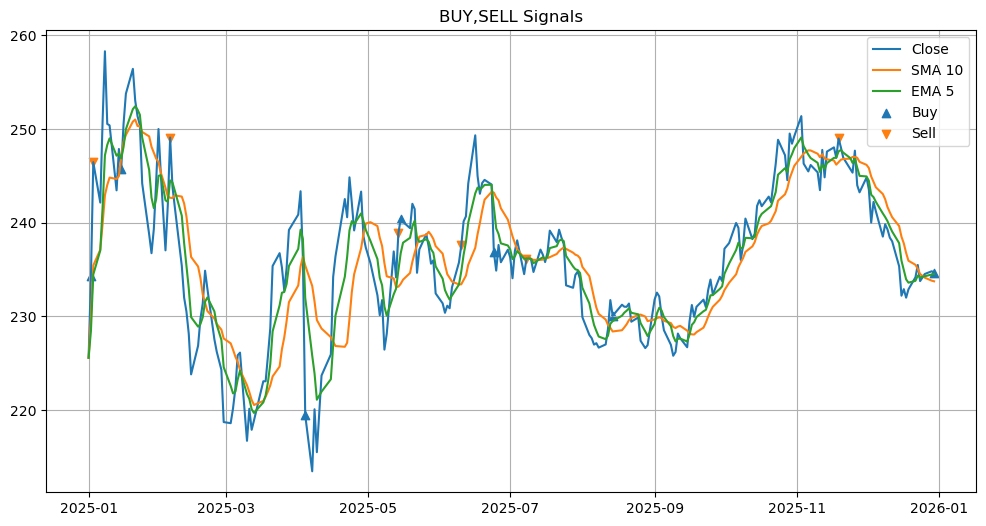

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def download_and_prepare_data(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    close = df['Close'].squeeze()
    df = pd.DataFrame({'Close': close})
    return df

def calculate_sma(df, period=10):
    df['sma_10'] = df['Close'].rolling(window=period, min_periods=1).mean()
    return df

def calculate_ema(df, fast_period=5, slow_period=21):
    df['ema_5'] = df['Close'].ewm(span=fast_period, adjust=False).mean()
    df['ema_slow'] = df['Close'].ewm(span=slow_period, adjust=False).mean()
    return df

def calculate_rsi(df, rsi_period=14):
    delta = df['Close'].diff()
    gain = np.where(delta > 0, delta, 0.0)
    loss = np.where(delta < 0, -delta, 0.0)
    gain = pd.Series(gain, index=df.index)
    loss = pd.Series(loss, index=df.index)
    avg_gain = gain.rolling(window=rsi_period, min_periods=1).mean()
    avg_loss = loss.rolling(window=rsi_period, min_periods=1).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    df['rsi'] = 100 - (100 / (1 + rs))
    return df

def calculate_macd(df, macd_fast=12, macd_slow=26, macd_signal=9):
    macd_line = df['Close'].ewm(span=macd_fast, adjust=False).mean() - \
                df['Close'].ewm(span=macd_slow, adjust=False).mean()
    df['macd'] = macd_line
    df['macd_signal'] = macd_line.ewm(span=macd_signal, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    return df

def calculate_bollinger_bands(df, window=20, std=2):
    df['bb_mid'] = df['Close'].rolling(window=window, min_periods=1).mean()
    df['bb_std'] = df['Close'].rolling(window=window, min_periods=1).std()
    df['bb_upper'] = df['bb_mid'] + std * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - std * df['bb_std']
    return df

def calculate_price_ratios(df):
    df['price_vs_sma_10'] = df['Close'] / df['sma_10']
    df['price_vs_ema_5'] = df['Close'] / df['ema_5']
    return df

def determine_regime(row):
    sma_ema_bull = row['sma_10'] > row['ema_5']
    rsi_bull = row['rsi'] > 50
    rsi_bear = row['rsi'] < 50
    
    if sma_ema_bull and rsi_bull:
        return 'bullish'
    elif not sma_ema_bull and rsi_bear:
        return 'bearish'
    else:
        return 'neutral'

def generate_signals(df):
    df['signal'] = 0
    df['regime'] = df.apply(determine_regime, axis=1)
    position = 0
    entry_high = 0
    for i in range(1, len(df)):
        row = df.iloc[i]
        prev_row = df.iloc[i-1]
        regime = row['regime']
        if position == 1 and entry_high > 0:
            stop_price = entry_high * 0.95
            if row['Close'] <= stop_price:
                df.iloc[i, df.columns.get_loc('signal')] = -1
                position = 0
                entry_high = 0
                continue
        if regime == 'bullish':
            if position == 0:
                sma_ema_cross_up = (prev_row['sma_10'] <= prev_row['ema_5'] and row['sma_10'] > row['ema_5'])
                rsi_bounce = row['rsi'] < 35 and row['rsi'] > prev_row['rsi']
                price_pullback = (row['price_vs_ema_5'] <= 0.98 and row['price_vs_ema_5'] > prev_row['price_vs_ema_5'])
                
                if sma_ema_cross_up or rsi_bounce or price_pullback:
                    df.iloc[i, df.columns.get_loc('signal')] = 1
                    position = 1
                    entry_high = row['Close']
            elif position == 1:
                exit_condition = (row['rsi'] > 75 or row['Close'] >= row['bb_upper'] or (prev_row['sma_10'] >= prev_row['ema_5'] and  row['sma_10'] < row['ema_5']))
                if exit_condition:
                    df.iloc[i, df.columns.get_loc('signal')] = -1
                    position = 0
                    entry_high = 0
        
        elif regime == 'bearish':
            if position == 0:
                macd_bull_div = (row['macd_hist'] > 0 and prev_row['macd_hist'] <= 0)
                price_oversold = row['rsi'] < 30
                
                if macd_bull_div or price_oversold:
                    df.iloc[i, df.columns.get_loc('signal')] = 1
                    position = 1
                    entry_high = row['Close']
            
            elif position == 1:
                if row['rsi'] > 60 or row['macd_hist'] < 0:
                    df.iloc[i, df.columns.get_loc('signal')] = -1
                    position = 0
                    entry_high = 0
    
    return df

def calculate_positions(df):
    df['position'] = 0
    pos = 0
    for i in range(len(df)):
        if df.iloc[i]['signal'] == 1:
            pos = 1
        elif df.iloc[i]['signal'] == -1:
            pos = 0
        df.iloc[i, df.columns.get_loc('position')] = pos
    df['position'] = df['position'].shift(1).fillna(0)
    return df

def create_daily_tradebook(df):
    book = df.loc[:,['Close', 'ema_5', 'sma_10', 'macd', 'rsi','bb_upper','bb_lower','signal']].copy()
    book['Date'] = book.index
    book = book.reset_index(drop=True)
    book['signal_label'] = book['signal'].map({ 1: 'BUY', -1: 'SELL', 0: 'HOLD'})
    return book[['Date', 'Close', 'ema_5', 'sma_10', 'macd', 'rsi','bb_upper','bb_lower','signal']]

TICKER = "ONGC.NS"
START_DATE = "2025-01-01"
END_DATE = "2025-12-31"

df = download_and_prepare_data(TICKER, START_DATE, END_DATE)
df = calculate_sma(df)
df = calculate_ema(df)
df = calculate_rsi(df)
df = calculate_macd(df)
df = calculate_bollinger_bands(df)
df = calculate_price_ratios(df)
df = generate_signals(df)
df = calculate_positions(df)

daily_tradebook = create_daily_tradebook(df)
daily_tradebook.to_csv('Tradebook_Maniteja.csv', index=False)
print("Daily tradebook saved as: 'Tradebook_Maniteja.csv'")

buy = df[df["signal"] == 1]
sell = df[df["signal"] == -1]
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Close")
plt.plot(df.index, df["sma_10"], label="SMA 10")
plt.plot(df.index, df["ema_5"], label="EMA 5")
plt.scatter(buy.index, buy["Close"], marker="^", label="Buy")
plt.scatter(sell.index, sell["Close"], marker="v", label="Sell")
plt.title("BUY,SELL Signals")
plt.legend()
plt.grid(True)
plt.show()